# Aufgabenblatt 4

<p style="background-color:#f6f6f6;border-left:5px solid red;padding:0.6em;box-sizing:border-box;">
<strong>Lernziele:</strong><br/>
    In dieser Übung beschäftigen wir uns mit Messfehlern, sowie der Gaussschen Fehlerfortpflanzung.
</p>

<p style="background-color:#f6f6f6;border-left:5px solid blue;padding:0.6em;box-sizing:border-box;">
<strong>Wichtigste neue Funktionen für diese Übung:</strong><br/>
    Dies sind die wichtigsten Funktionen, die Sie während dieser Übung benötigen:<br>
    Die jeweilige Syntax beschreibt eine examplarische Verwendung. Im Allgemeinen haben die Funktionen weitere Argumente, die übergeben werden können. Der Funktionsname ist jeweils ein Link zur offiziellen Dokumentation, welche alle Argumente darlegt und ihre Funktion beschreibt. <br>
    <b>Funktionen zur statistischen Analyse: </b><br>
    <a href="https://numpy.org/doc/stable/reference/generated/numpy.logspace.html">numpy.logspace(start, stop, num_samples)</a> Erstellt ein Array mit <em>num_samples</em> Einträgen zwischen <em>start</em> und <em>stop</em>. Die Werte sind dabei gleichmässig auf einer logarithmischen Skala verteilt.<br>
    <a href="https://numpy.org/doc/stable/reference/generated/numpy.mean.html">numpy.mean(data)</a> Berechnet den Mittelwert aller Werte im Array <em>data</em>. <br>
    <a href="https://numpy.org/doc/stable/reference/generated/numpy.std.html">numpy.std(data)</a> Berechnet die Standardabweichung aller Werte im Array <em>data</em>. <br>
    <a href="https://numpy.org/doc/stable/reference/generated/numpy.histogram.html">hist, bin_edges = numpy.histogram(data, number_of_bins)</a> Sortiert die Daten <em>data</em> in <em>number_of_bins</em> gleichgrossen Bins. Zurückgegeben werden zwei Arrays, welche die Grenzen (<em>bin_edges</em>) sowie die Popultaion der Bins (<em>hist</em>) enthalten.<br>
    <b>Funktionen zum Plotten: </b><br>
    <a href="https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.semilogx.html">axis.semilogx(x, y)</a> Plotted die Daten x,y in einem Grafen. Die x-Achse ist dabei in logarithmischer Basis dargestellt.<br>
    <a href="https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.set_yscale.html">axis.set_yscale({"linear", "log"})</a> Ändere die Darstellungsweise der y-Achse zu einer linearen oder logarithmischen Skala.<br>
    <a href="https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.axhline.html">axis.axhline(y=1)</a> Füge dem aktuellen Grafen eine horizontale Linie hinzu. In diesem Fall bei y = 1.<br>
    <a href="https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.errorbar.html">axis.errorbar(x, y, xerr, yerr)</a> Plotte die Datenpunkte in den Arrays x,y. Die jeweiligen Punkte erhalten Fehlerbalken, deren Grössen in den Arrays xerr und yerr definiert sind.<br>
</p>

In [249]:
import numpy as np
import matplotlib.pyplot as plt

# Aufgabe 1 Fehler des Mittelwertes

Wie Sie in der Vorlesung gesehen haben, kann der Fehler des Mittelwertes reduziert werden, indem mehr Datenpunkte gesammelt werden. Er hängt also damit zusammen, wie viel Information man über die Normalverteilung hat, und je mehr Datenpunkte man hat, desto genauer gleicht die Verteilung der Daten der Normalverteilung. Obwohl die Unsicherheit der einzelnen Datenpunkte gegebenenfalls gross sein kann, kann also die Unsicherheit des Mittelwertes beliebig klein werden. 

In dieser Aufgabe untersuchen Sie den Mittelwert und dessen Fehler als Funktion der Anzahl Datenpunkte, und vergleichen Ihr Ergebnis mit den Histogrammen der Datenpunkte.

## a)

Laden Sie dazu zuerst den Datensatz `ExampleData.txt`.

In [250]:
data = np.loadtxt('ExampleData.txt')
print(data)
print(len(data))

[5.7434276  4.54517845 6.17394323 ... 4.73277996 6.8419649  6.36283586]
100000


## b)

Als nächstes berechnen Sie den Mittelwert, die Standardabweichung  und den Fehler des Mittelwerts als Funktion der Anzahl der berücksichtigten Datenpunkte und stellen diese grafisch dar. Nehmen Sie dazu zuerst nur die ersten $n=10$ Punkte des Datensatzes und berechnen Sie davon den Mittelwert $\bar{x}_n$, die Standardabweichung $\sigma$ und den theoretisch erwarteten Fehler des Mittelwertes $\sigma_{\bar{x}_n}$. Wiederholen Sie dies für zunehmende $n$, bis Sie schliesslich alle Datenpunkte berücksichtigen. 
Speichern Sie die berechneten Werte für jedes $n$ in einem Array, so dass Sie am Ende alles als Funktion von $n$ plotten können.
Vergleichen Sie auch den theoretisch erwarteten Fehler mit der Abweichung von $\bar{x}_n$ zum echten Mittelwert $\mu$, der für diesen Datensatz $\mu=5$ ist. 

Da es sich hier um mehrere Grössenordnungen handelt, ist es vorteilhaft, mit `np.logspace` die Anzahl Punkte zu definieren und mit `ax.semilogx` die Resultate zu plotten.

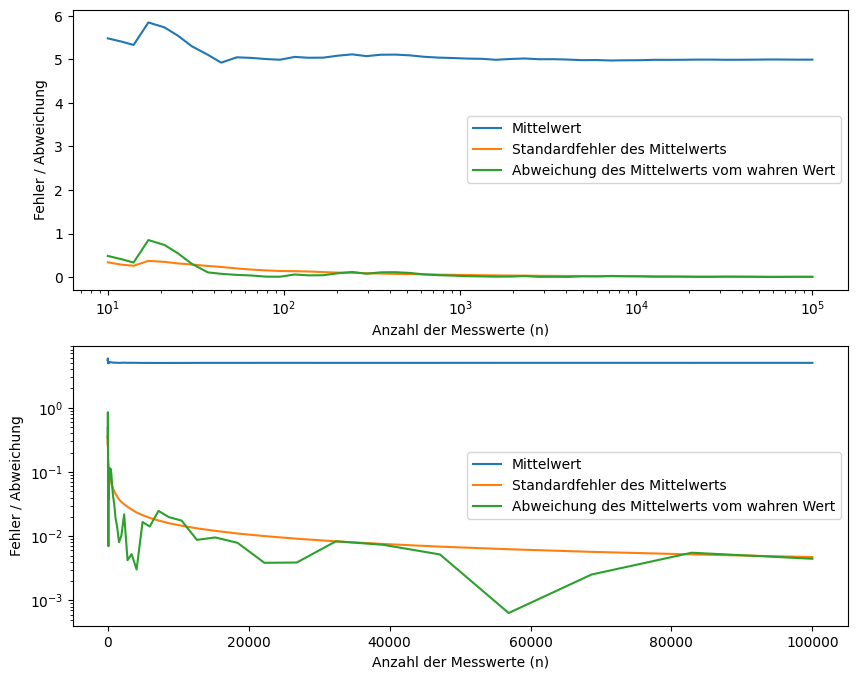

In [251]:
n_values = np.logspace(1, 5, 50).astype(int)

means = []
stds = []
mean_errors = []
deviations = []

mu_true = 5


for n in n_values:
    data_sample = data[:n]
    means.append(np.mean(data_sample))
    stds.append(np.std(data_sample, ddof=1))
    mean_errors.append(np.std(data_sample, ddof=1) / np.sqrt(n))
    deviations.append(np.abs(np.mean(data_sample) - mu_true))

fig = plt.figure(figsize=(10, 8))
ax1 = fig.add_subplot(2, 1, 1)
ax1.semilogx(n_values, means, label='Mittelwert')
ax1.semilogx(n_values, mean_errors, label='Standardfehler des Mittelwerts')
ax1.semilogx(n_values, deviations, label='Abweichung des Mittelwerts vom wahren Wert')
ax1.set_xlabel('Anzahl der Messwerte (n)')
ax1.set_ylabel('Fehler / Abweichung')
ax1.legend()
ax2 = fig.add_subplot(2, 1, 2)
ax2.semilogy(n_values, means, label='Mittelwert')
ax2.semilogy(n_values, mean_errors, label='Standardfehler des Mittelwerts')
ax2.semilogy(n_values, deviations, label='Abweichung des Mittelwerts vom wahren Wert')
ax2.set_xlabel('Anzahl der Messwerte (n)')
ax2.set_ylabel('Fehler / Abweichung')
ax2.legend()




## c)

Vergleichen Sie die Mittelwerte und deren Unsicherheiten mit den Verteilungen der Datenpunkte. Plotten Sie dazu die Histogramme für 10, 100, 1'000 und 10'000 Punkte, und zeichnen Sie die dazugehörigen Mittelwerte mit deren Unsicherheiten ein.

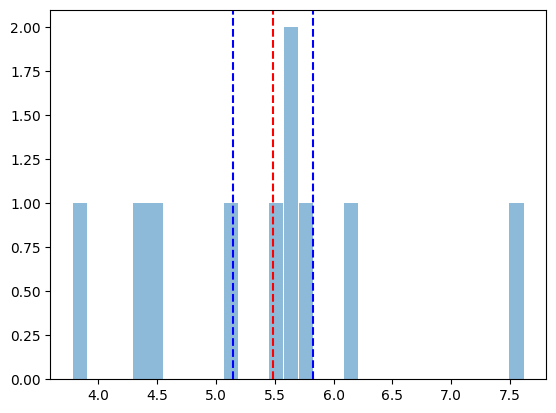

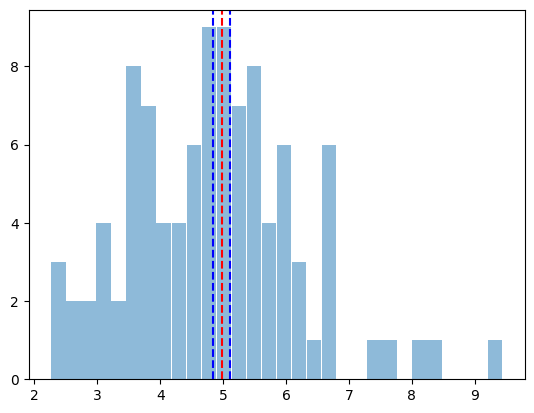

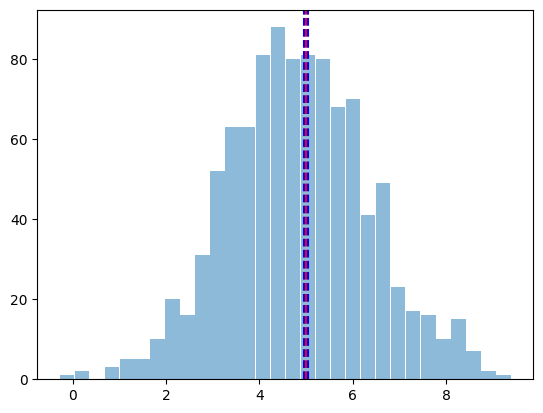

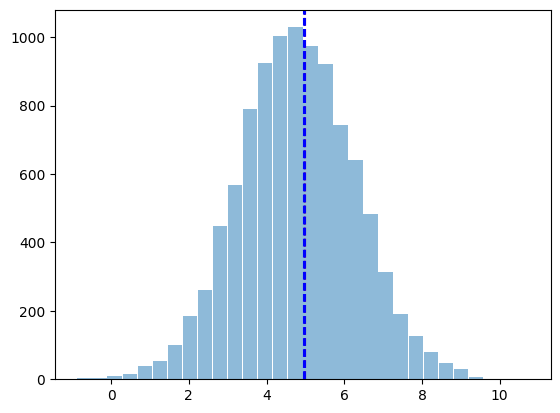

In [252]:
# Ihr Code
from scipy.interpolate import interp1d

def interpolate_histogram(counts, bin_edges, num_points=1000):
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2  # midpoint of each bin
    f = interp1d(bin_centers, counts, kind='cubic')
    
    x_smooth = np.linspace(bin_centers[0], bin_centers[-1], num_points)
    y_smooth = f(x_smooth)
    return x_smooth, y_smooth, bin_centers

def plot_histogram(data, bins=10, interpolate=False, bin_width=0.96, show_mean=False, show_std=False, show_mean_error=False):
    counts, bin_edges = np.histogram(data, bins=bins)
    fig, ax = plt.subplots()
    ax.bar(bin_edges[:-1], counts, width=np.diff(bin_edges) * bin_width, alpha=0.5)
    
    if interpolate:
        x_smooth, y_smooth, centers = interpolate_histogram(counts, bin_edges)
        ax.plot(x_smooth, y_smooth, color='red')

    m = np.mean(data)
    s = np.std(data, ddof=1)

    if show_mean:
        ax.axvline(m, color='red', linestyle='--', label='Mittelwert')
    if show_std:
        ax.axvline(m + s, color='green', linestyle='--', label='+1 Std')
        ax.axvline(m - s, color='green', linestyle='--', label='-1 Std')
    if show_mean_error:
        mean_error = s / np.sqrt(len(data))
        ax.axvline(m + mean_error, color='blue', linestyle='--', label='Mittelwert + Standardfehler')
        ax.axvline(m - mean_error, color='blue', linestyle='--', label='Mittelwert - Standardfehler')
    return ax  # return ax so other functions can draw on it

def plot_normal_distribution(data, ax, apply_scale=False):
    m = np.mean(data)
    s = np.std(data, ddof=1)
    x = np.linspace(m - 4*s, m + 4*s, 1000)
    y = (1 / (s * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - m) / s) ** 2)
    y_scaled = y * len(data)
    ax.plot(x, y_scaled, color='blue')

    if apply_scale:
        ax.set_xlim(m - 4*s, m + 4*s)
        ax.set_ylim(0, np.max(y_scaled) * 1.1)

n_bins = [10, 100, 1000, 10000]

for bins in n_bins:
    plot_histogram(data[:bins], bins=30, show_mean=True, show_mean_error=True)

# Aufgabe 2 Fehler des Mittelwerts mit Gauss

Leiten Sie die Unsicherheit des Mittelwerts mithilfe der Gaussschen Fehlerfortpflanzung her. Nehmen Sie dazu an, dass alle Datenpunkte die gleiche Unsicherheit $\sigma$ haben.

# Aufgabe 3 Gausssche Fehlerfortpflanzung

In vielen Experimenten wird nicht die gesuchte Grösse direkt gemessen, sondern diese muss erst aus den gesammelten Daten berechnet werden. In dieser Aufgabe werden Sie die Fehler einer solchen Grösse durch Fehlerfortpflanzung der Unsicherheit normalverteilter Werte berechnen.

Als System betrachten wir dazu eine Masse $m$, die sich mit einer Geschwindigkeit $v$ auf einer Kreisbahn mit Radius $R$ bewegt. Nun soll für verschiedene Geschwindigkeiten die Kraft berechnet werden, mit der die Masse auf der Kreisbahn gehalten wird. Die Geschwindigkeiten und ihre Standardabweichungen können dabei aus der Datei `Geschwindigkeiten.txt` entnommen werden. Die zusätzlichen Werte sind:

$m$  | $R$
---|---
0.1 $\pm$ 0.001 kg| 0.15 $\pm$ 0.001 m

## a)

Laden Sie zuerst den Datensatz.

In [253]:
# Ihr Code
data = np.loadtxt('Geschwindigkeiten.txt', skiprows=3, delimiter=' ');
v = data[0, :]
v_sigma = data[1, :]

m_mean = 0.1
m_sigma = 0.001

R_mean = 0.15
R_sigma = 0.001

# plot_histogram(v, bins=30, show_mean=True, show_std=True);


## b)

Berechnen Sie nun die Unsicherheit der Zentripetalkraft mit der Gaussschen Fehlerfortpflanzung. Vergleichen Sie die einzelnen Terme in der Summe. Gibt es Terme, die Sie vernachlässigen können?

Tipp: Sie können mit `ax.set_yscale` auf eine logarithmische Skala auf der y-Achse wechseln.

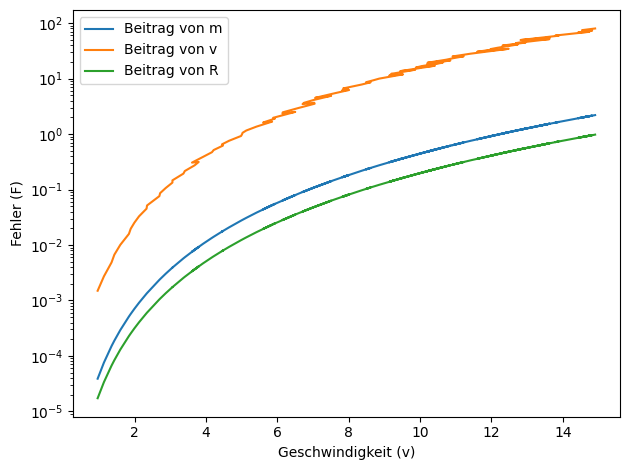

In [254]:
# Ihr Code
F = m_mean * v**2 / R_mean
dF_dm = v**2 / R_mean
dF_dv = 2 * m_mean * v / R_mean
dF_dR = -m_mean * v**2 / R_mean**2

term_m = (dF_dm * m_sigma)**2
term_v = (dF_dv * v_sigma)**2
term_R = (dF_dR * R_sigma)**2

F_sigma = np.sqrt(term_m + term_v + term_R)

# fig = plt.figure(figsize=(10, 8))
# ax1 = fig.add_subplot(1, 1, 1)
# ax1.semilogy(v, term_m, label='Beitrag von m')
# ax1.semilogy(v, term_v, label='Beitrag von v')
# ax1.semilogy(v, term_R, label='Beitrag von R')
# ax1.set_xlabel('Geschwindigkeit (v)')
# ax1.set_ylabel('Fehler (F)')
# ax1.legend()

def plot_plot(*data_pairs, xlabel='x', ylabel='y', scale='linear', title=''):
    fig = plt.figure()
    ax = fig.add_subplot(1, 1, 1)
    for pair in data_pairs:
        if len(pair) == 1:
            y, label = pair[0], ''
            x = np.arange(len(y))
        elif len(pair) == 2:
            y, label = pair[0], pair[1]
            x = np.arange(len(y))
        else:
            x, y, label = pair[0], pair[1], pair[2]
        yerr = pair[3] if len(pair) > 3 else None
        fmt = pair[4] if len(pair) > 4 else '-'
        ax.errorbar(x, y, yerr=yerr, fmt=fmt, capsize=5, label=label)
    
    if scale == 'logx':
        ax.set_xscale('log')
    elif scale == 'logy':
        ax.set_yscale('log')
    elif scale == 'loglog':
        ax.set_xscale('log')
        ax.set_yscale('log')
    
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()
    fig.tight_layout()




plot_plot(
    (v, term_m, 'Beitrag von m'),
    (v, term_v, 'Beitrag von v'),
    (v, term_R, 'Beitrag von R'),
    xlabel='Geschwindigkeit (v)',
    ylabel='Fehler (F)',
    scale='logy'
)


## c)

Plotten Sie nun die Kraft zusammen mit den Fehlern in Abhängigkeit der gemessenen Geschwindigkeit. Sie können dazu `ax.errorbar()` benutzen. 

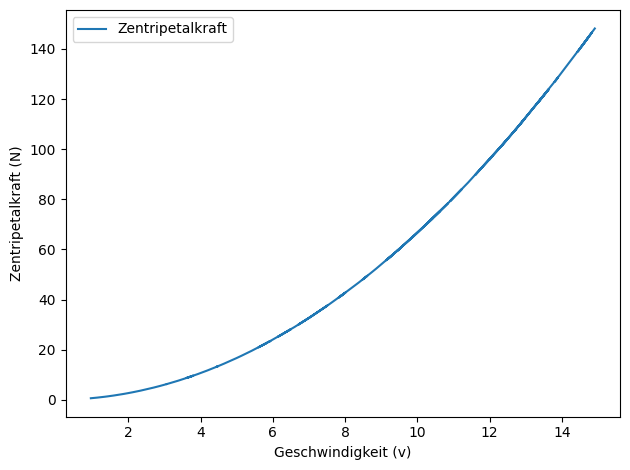

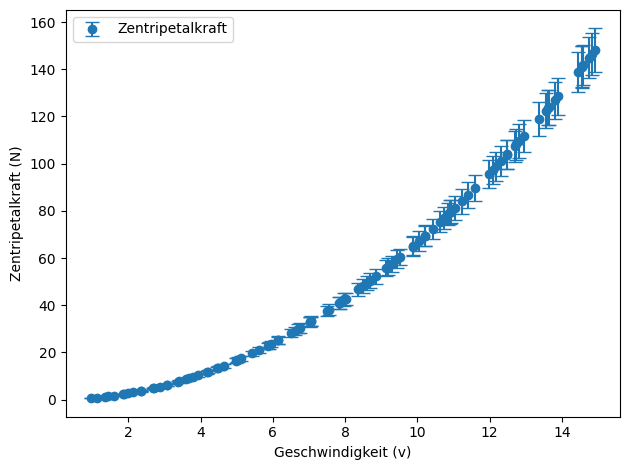

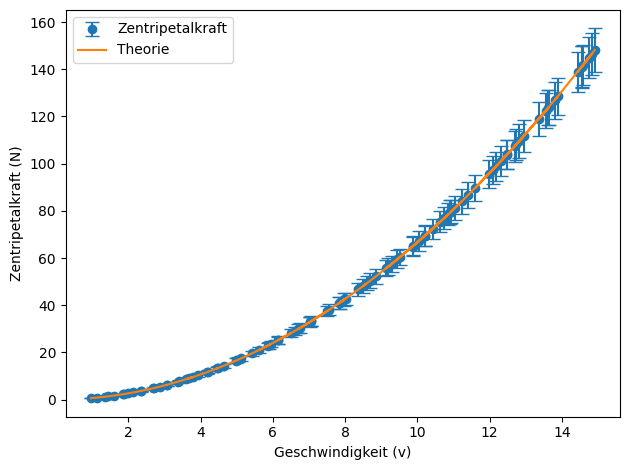

In [255]:
# Ihr Code
# line plot (no error bars)
plot_plot(
    (v, F, 'Zentripetalkraft'),
    xlabel='Geschwindigkeit (v)',
    ylabel='Zentripetalkraft (N)',
)

# dots with error bars
plot_plot(
    (v, F, 'Zentripetalkraft', F_sigma, 'o'),
    xlabel='Geschwindigkeit (v)',
    ylabel='Zentripetalkraft (N)',
)

# mix both
plot_plot(
    (v, F, 'Zentripetalkraft', F_sigma, 'o'),
    (v, F, 'Theorie'),
    xlabel='Geschwindigkeit (v)',
    ylabel='Zentripetalkraft (N)',
)


## Aufgabe 4 Gausssche Fehlerfortpflanzung

Wir betrachten den exponentiellen Zerfall der Population eines beliebigen Systems (z.B. eines radioaktiven Isotops), gegeben durch $N(t) = N_0e^{-\frac{t}{\tau}}$. Um die Zerfallszeit $\tau$ zu bestimmen, wird wiederholt die Anfangspopulation $N_0$ und die Population $N(t)$ nach einer Zeit $t$ gemessen.

## a)

Berechnen Sie die Unsicherheit $\sigma_\tau$ der Zerfallszeit abhängig von den Unsicherheiten der Population ($\sigma_N$) und der gemessenen Zeit ($\sigma_t$).

In [256]:
data_1 = np.loadtxt('Population1.txt', skiprows=2, delimiter=' ')
data_2 = np.loadtxt('Population2.txt', skiprows=2, delimiter=' ')

N0_1 = data_1[0, :]
N0_2 = data_2[0, :]

Nt_1 = data_1[1, :]
Nt_2 = data_2[1, :]

t = 20
tau_1 = -t / np.log(Nt_1 / N0_1)
tau_2 = -t / np.log(Nt_2 / N0_2)

## b)

Laden Sie nun die Datensätze `Population1.txt` und `Population2.txt`. Sie beinhalten die wiederholte Messung von $N_0$ sowie $N(t=20s)$, wobei der zweite Datensatz mit einem Detektor mit einer grösseren Unsicherheit gemessen wurde. Nehmen Sie an, dass die Unsicherheit in der Zeit vernachlässigbar ist, und plotten Sie die Histogramme der Zerfallskonstanten. Was können Sie beobachten?

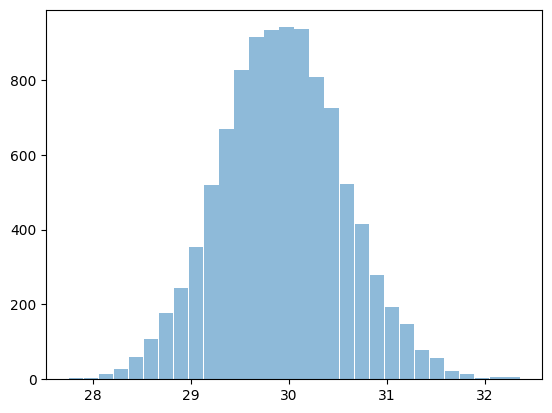

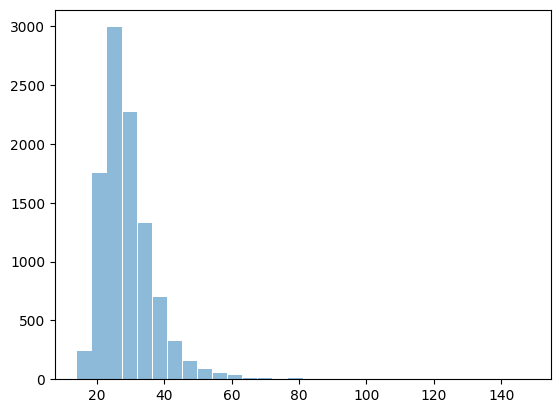

In [257]:
# Ihr Code

plot_histogram(tau_1, bins=30);
plot_histogram(tau_2, bins=30);

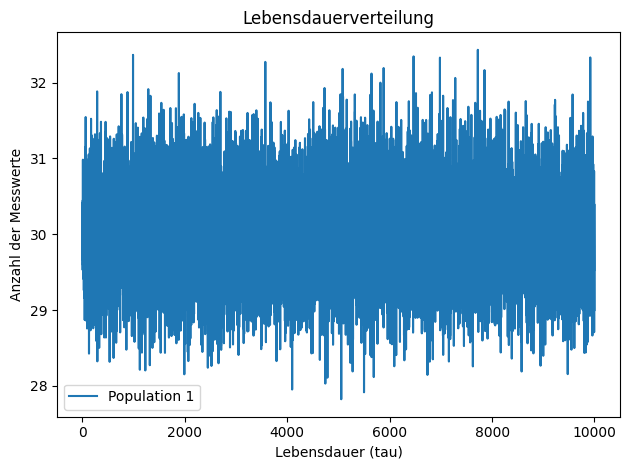

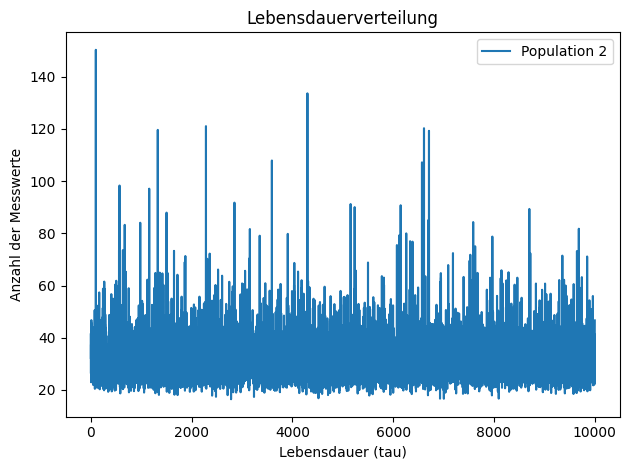

In [258]:
plot_plot(
    (tau_1, 'Population 1'),
    xlabel='Lebensdauer (tau)',
    ylabel='Anzahl der Messwerte',
    title='Lebensdauerverteilung'
)

plot_plot(
    (tau_2, 'Population 2'),
    xlabel='Lebensdauer (tau)',
    ylabel='Anzahl der Messwerte',
    title='Lebensdauerverteilung'
)